# Ahmed Mohamed Fahmy 231000587
# Myar Saad Sadek 231000687
# Nadeem Diaa Shokry 231000857
# Omar Salama Isleem 231000674

# Imports

In [ ]:
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from google.colab import drive
from matplotlib.patches import FancyBboxPatch
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score,
    precision_score, precision_recall_curve, recall_score, roc_auc_score,
    roc_curve, RocCurveDisplay,make_scorer
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from scipy.stats import loguniform, uniform
import lightgbm as lgb
import pickle
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.3 MB/s eta 0:00:00


# اساسيات

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/Alzheimer-Progression-Prediction/Data/Processed/'

df = pd.read_csv(path + 'df_clean_AD.csv')

display(df.head())
df.info()

,TOTSCORE,TOTAL13,FAQTOTAL,BRAINVOL,VENTVOL,AVDEL30MIN,AVDELTOT,CATANIMSC,TOTAL_HIPPO,APOE4_COUNT,...,PTMARRY,AGE,MMSCORE,CDRSB,LIMMTOTAL,LDELTOTAL,RID,MONTH,PROGRESSOR,RAVLT_AVERAGE
0,10.670000,18.67,0.0,1251.47,88.025299,5.0,6.000000,15.0,5.838222,0,...,1,74.496920,28.0,0.0,14.0,11.0,2,0.0,0,8.166667
1,21.976315,31.00,10.0,1186.02,88.005000,0.0,1.921344,10.0,5.838816,1,...,1,81.415469,20.0,4.5,6.0,2.0,3,0.0,1,4.166667
2,14.330000,21.33,0.0,1178.02,43.714000,7.0,13.000000,22.0,6.539448,0,...,1,67.852156,27.0,1.0,5.0,4.0,4,0.0,0,7.166667
3,8.670000,14.67,0.0,1176.69,35.972000,5.0,15.000000,19.0,7.125336,0,...,1,73.831622,29.0,0.0,13.0,12.0,5,0.0,0,6.833333
4,18.670000,25.67,0.0,993.96,41.763000,1.0,7.000000,13.0,5.775653,0,...,1,80.501027,25.0,0.5,6.0,3.0,6,0.0,0,5.666667


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2937 entries, 0 to 2936
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TOTSCORE       2937 non-null   float64
 1   TOTAL13        2937 non-null   float64
 2   FAQTOTAL       2937 non-null   float64
 3   BRAINVOL       2937 non-null   float64
 4   VENTVOL        2937 non-null   float64
 5   AVDEL30MIN     2937 non-null   float64
 6   AVDELTOT       2937 non-null   float64
 7   CATANIMSC      2937 non-null   float64
 8   TOTAL_HIPPO    2937 non-null   float64
 9   APOE4_COUNT    2937 non-null   int64  
 10  DIAGNOSIS      2937 non-null   int64  
 11  PTGENDER       2937 non-null   float64
 12  PTEDUCAT       2937 non-null   float64
 13  PTMARRY        2937 non-null   int64  
 14  AGE            2937 non-null   float64
 15  MMSCORE        2937 non-null   float64
 16  CDRSB          2937 non-null   float64
 17  LIMMTOTAL      2937 non-null   float64
 18  LDELTOTA

In [ ]:
df.PROGRESSOR.value_counts()

,count
PROGRESSOR,
0,2304
1,633


# GENERAL USE IN ALL MODELS

In [ ]:
# ME COOK
# U WATCH
PALETTE = ["#6C63FF", "#00C896", "#FF6B6B", "#FFC857", "#4CC9F0"]
model_features = [
    'PTGENDER',
    'PTEDUCAT',
    'PTMARRY',
    'APOE4_COUNT',
    'AGE',
    'LIMMTOTAL',
    'LDELTOTAL',
    'AVDEL30MIN',
    'AVDELTOT',
    'CATANIMSC',
    'MMSCORE',
    'CDRSB',
    'FAQTOTAL',
    'TOTSCORE',
    'TOTAL13',
    'BRAINVOL',
    'VENTVOL',
    'TOTAL_HIPPO',
    'RAVLT_AVERAGE']



scale_features = [f for f in model_features if f not in ['PTGENDER']]

X = df[model_features].copy()
y = df['PROGRESSOR'].copy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Dataset: {X.shape[0]} samples | {X.shape[1]} features")
print(f"Progressors: {y.sum()} ({y.mean()*100:.1f}%)")
print(f"\n✅ Ready — use X, y, skf, scale_features in all models")


Dataset: 2937 samples | 19 features
Progressors: 633 (21.6%)

✅ Ready — use X, y, skf, scale_features in all models


# Logistic Reg

In [ ]:
# omar
# U WATCH C class_weight  l1_ratio  max_iter penalty solver
lr_model = LogisticRegression(
    penalty='l1',
    C=0.577493255516795,
    class_weight='balanced',
    solver='saga',
    max_iter=1000,
    random_state=42
)
fold_metrics = []
fold_data    = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr,  X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr,  y_val = y.iloc[train_idx],         y.iloc[val_idx]

    scaler = StandardScaler()
    X_tr[scale_features]  = scaler.fit_transform(X_tr[scale_features])
    X_val[scale_features] = scaler.transform(X_val[scale_features])

    lr_model.fit(X_tr, y_tr)

    y_pred  = lr_model.predict(X_val)
    y_proba = lr_model.predict_proba(X_val)[:, 1]

        # --- train preds (for overfit check) ---
    y_pred_tr  = lr_model.predict(X_tr)
    y_proba_tr = lr_model.predict_proba(X_tr)[:, 1]


    fold_metrics.append({
           "fold":      fold,
            "roc_auc":   roc_auc_score(y_val, y_proba),
            "accuracy":  accuracy_score(y_val, y_pred),
            "recall":    recall_score(y_val, y_pred),
            "precision": precision_score(y_val, y_pred, zero_division=0),
            "f1_score":  f1_score(y_val, y_pred, zero_division=0),
            "pr_auc":    average_precision_score(y_val, y_proba),
            "train_roc_auc":  roc_auc_score(y_tr, y_proba_tr),
            "train_accuracy": accuracy_score(y_tr, y_pred_tr),
            "train_recall":   recall_score(y_tr, y_pred_tr),
            "train_precision":precision_score(y_tr, y_pred_tr, zero_division=0),
            "train_f1":       f1_score(y_tr, y_pred_tr, zero_division=0),
            "train_pr_auc":   average_precision_score(y_tr, y_proba_tr),
        })
    fold_data.append((y_val, y_pred, y_proba))

metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
best_fold  = int(metrics_df["f1_score"].idxmax())



In [ ]:
cols    = ["roc_auc", "accuracy", "recall", "precision", "f1_score", "pr_auc"]
headers = ["Fold", "ROC-AUC", "Accuracy", "Recall", "Precision", "F1", "PR-AUC"]
col_w   = 10
sep     = "┼".join(["─" * col_w] * len(headers))

print(f"\n  {'Logistic Regression results':^{col_w * len(headers)}}")
print("  ┌" + "┬".join(["─" * col_w] * len(headers)) + "┐")
print("  │" + "│".join(h.center(col_w) for h in headers) + "│")
print("  ├" + sep + "┤")

for fold, row in metrics_df.iterrows():
    marker = f" ★Fold {fold}" if fold == best_fold else f"  Fold {fold}"
    cells  = [marker.ljust(col_w)]
    for c in cols:
        cells.append(f"{row[c]:.3f}".center(col_w))
    print("  │" + "│".join(cells) + "│")

print("  ├" + sep + "┤")
avg_cells = [" Mean".ljust(col_w)]
std_cells = [" Std".ljust(col_w)]
for c in cols:
    avg_cells.append(f"{metrics_df[c].mean():.3f}".center(col_w))
    std_cells.append(f"±{metrics_df[c].std():.3f}".center(col_w))
print("  │" + "│".join(avg_cells) + "│")
print("  │" + "│".join(std_cells) + "│")
print("  └" + "┴".join(["─" * col_w] * len(headers)) + "┘\n")

# ── Overfit / underfit diagnostics ──────────────────────────────────────────
metric_map = {
    "roc_auc": ("roc_auc",  "train_roc_auc"),
    "f1":      ("f1_score", "train_f1"),
    "pr_auc":  ("pr_auc",   "train_pr_auc"),
}

diag_headers = ["Metric", "Train", "Val", "Gap", "Status"]
diag_widths  = [14, 10, 10, 10, 14]
diag_sep     = "┼".join("─" * w for w in diag_widths)

print(f"\n  {'Fit Diagnostics':^{sum(diag_widths) + len(diag_widths) - 1}}")
print("  ┌" + "┬".join("─" * w for w in diag_widths) + "┐")
print("  │" + "│".join(h.center(w) for h, w in zip(diag_headers, diag_widths)) + "│")
print("  ├" + diag_sep + "┤")

flags = {}
for label, (val_col, tr_col) in metric_map.items():
    tr  = metrics_df[tr_col].mean()
    val = metrics_df[val_col].mean()
    gap = tr - val
    if gap > 0.10:
        flag = "⚠ overfit"
    elif val < 0.60:
        flag = "⚠ underfit"
    else:
        flag = "✓ ok"
    flags[label] = flag
    cells = [
        label.center(diag_widths[0]),
        f"{tr:.4f}".center(diag_widths[1]),
        f"{val:.4f}".center(diag_widths[2]),
        f"{gap:+.4f}".center(diag_widths[3]),
        flag.center(diag_widths[4]),
    ]
    print("  │" + "│".join(cells) + "│")

print("  └" + "┴".join("─" * w for w in diag_widths) + "┘")

# ── Summary banner ────────────────────────────────────────────────────────────
total_w = sum(diag_widths) + len(diag_widths) - 1
all_flags = list(flags.values())
if all(f == "✓ ok" for f in all_flags):
    verdict = "✓  Model fit looks healthy across all metrics"
elif any("overfit" in f for f in all_flags):
    bad = [k for k, v in flags.items() if "overfit" in v]
    verdict = f"⚠  Overfitting detected on: {', '.join(bad)}"
else:
    bad = [k for k, v in flags.items() if "underfit" in v]
    verdict = f"⚠  Underfitting detected on: {', '.join(bad)}"

print("  ┌" + "─" * total_w + "┐")
print("  │" + verdict.center(total_w) + "│")
print("  └" + "─" * total_w + "┘\n")


                       Logistic Regression results                      
  ┌──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
  │   Fold   │ ROC-AUC  │ Accuracy │  Recall  │Precision │    F1    │  PR-AUC  │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │  Fold 1  │  0.959   │  0.883   │  0.913   │  0.667   │  0.771   │  0.876   │
  │  Fold 2  │  0.966   │  0.905   │  0.929   │  0.715   │  0.808   │  0.899   │
  │ ★Fold 3  │  0.960   │  0.915   │  0.944   │  0.735   │  0.826   │  0.875   │
  │  Fold 4  │  0.954   │  0.876   │  0.889   │  0.655   │  0.754   │  0.889   │
  │  Fold 5  │  0.934   │  0.864   │  0.811   │  0.648   │  0.720   │  0.809   │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │ Mean     │  0.954   │  0.888   │  0.897   │  0.684   │  0.776   │  0.870   │
  │ Std      │  ±0.012  │  ±0.021  │  ±0.052  │  ±0.039  │  ±0.042  │  ±0.035  │
  └──────────┴──────────┴──────────

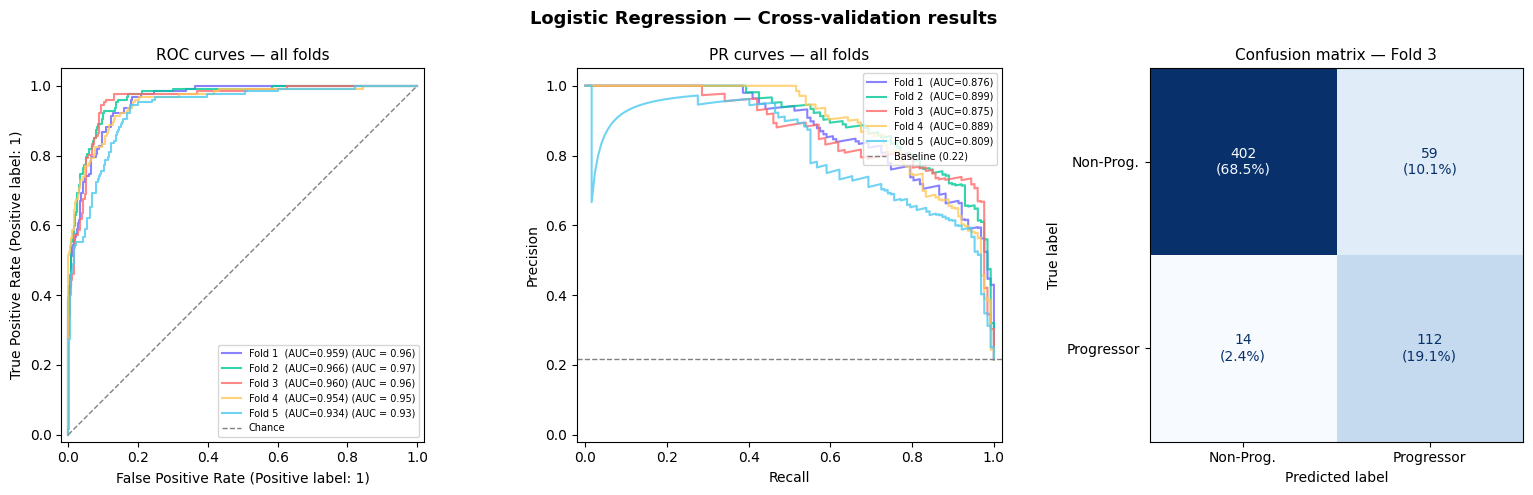

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Logistic Regression — Cross-validation results", fontsize=13, fontweight="bold")

# ── ROC curves (all folds) ────────────────────────────────────────────────
ax = axes[0]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    auc = metrics_df.loc[fold_num, "roc_auc"]
    RocCurveDisplay.from_predictions(
        y_val, y_proba, ax=ax,
        name=f"Fold {fold_num}  (AUC={auc:.3f})",
        color=PALETTE[idx % len(PALETTE)],
        lw=1.5, alpha=0.8,
    )
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Chance")
ax.set_title("ROC curves — all folds", fontsize=11)
ax.legend(fontsize=7, loc="lower right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── PR curves (all folds) ─────────────────────────────────────────────────
ax = axes[1]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    pr_auc = metrics_df.loc[fold_num, "pr_auc"]
    precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_proba)
    ax.plot(recall_vals, precision_vals,
            color=PALETTE[idx % len(PALETTE)],
            lw=1.5, alpha=0.8,
            label=f"Fold {fold_num}  (AUC={pr_auc:.3f})")
baseline = sum(fold_data[-1][0]) / len(fold_data[-1][0])
ax.axhline(baseline, linestyle="--", color="gray", lw=1, label=f"Baseline ({baseline:.2f})")
ax.set_title("PR curves — all folds", fontsize=11)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=7, loc="upper right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── Confusion matrix (last fold) ─────────────────────────────────────────
ax = axes[2]
y_val_last, y_pred_last, _ = fold_data[best_fold]
cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_val_last, y_pred_last,
    ax=ax,
    display_labels=["Non-Prog.", "Progressor"],
    colorbar=False,
    cmap="Blues",
)
total = len(y_val_last)
for text_obj in cm_disp.text_.ravel():
    count = int(text_obj.get_text())
    text_obj.set_text(f"{count}\n({count/total*100:.1f}%)")
    text_obj.set_fontsize(10)
ax.set_title(f"Confusion matrix — Fold {best_fold}", fontsize=11)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

# **SVM del chef**

In [ ]:
SVM_THRESHOLD = 0.2

svc_final = SVC(
    kernel='linear',
    C=1,
    class_weight='balanced',
    probability=True,
    random_state=42
)

fold_metrics = []
fold_data    = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr,  X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr,  y_val = y.iloc[train_idx],         y.iloc[val_idx]

    scaler = StandardScaler()
    X_tr[scale_features]  = scaler.fit_transform(X_tr[scale_features])
    X_val[scale_features] = scaler.transform(X_val[scale_features])

    svc_final.fit(X_tr, y_tr)

    y_proba = svc_final.predict_proba(X_val)[:, 1]
    y_pred  = (y_proba >= SVM_THRESHOLD).astype(int)

            # --- train preds (for overfit check) ---
    y_pred_tr  = svc_final.predict(X_tr)
    y_proba_tr = svc_final.predict_proba(X_tr)[:, 1]

    fold_metrics.append({
        "fold":      fold,
        "roc_auc":   roc_auc_score(y_val, y_proba),
        "accuracy":  accuracy_score(y_val, y_pred),
        "recall":    recall_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "f1_score":  f1_score(y_val, y_pred, zero_division=0),
        "pr_auc":    average_precision_score(y_val, y_proba),

        "train_roc_auc":  roc_auc_score(y_tr, y_proba_tr),
        "train_accuracy": accuracy_score(y_tr, y_pred_tr),
        "train_recall":   recall_score(y_tr, y_pred_tr),
        "train_precision":precision_score(y_tr, y_pred_tr, zero_division=0),
        "train_f1":       f1_score(y_tr, y_pred_tr, zero_division=0),
        "train_pr_auc":   average_precision_score(y_tr, y_proba_tr),
    })
    fold_data.append((y_val, y_pred, y_proba))

metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
best_fold  = int(metrics_df["f1_score"].idxmax())

In [ ]:
cols    = ["roc_auc", "accuracy", "recall", "precision", "f1_score", "pr_auc"]
headers = ["Fold", "ROC-AUC", "Accuracy", "Recall", "Precision", "F1", "PR-AUC"]
col_w   = 10
sep     = "┼".join(["─" * col_w] * len(headers))

print(f"\n  {'SVM Regression results':^{col_w * len(headers)}}")
print("  ┌" + "┬".join(["─" * col_w] * len(headers)) + "┐")
print("  │" + "│".join(h.center(col_w) for h in headers) + "│")
print("  ├" + sep + "┤")

for fold, row in metrics_df.iterrows():
    marker = f" ★Fold {fold}" if fold == best_fold else f"  Fold {fold}"
    cells  = [marker.ljust(col_w)]
    for c in cols:
        cells.append(f"{row[c]:.3f}".center(col_w))
    print("  │" + "│".join(cells) + "│")

print("  ├" + sep + "┤")
avg_cells = [" Mean".ljust(col_w)]
std_cells = [" Std".ljust(col_w)]
for c in cols:
    avg_cells.append(f"{metrics_df[c].mean():.3f}".center(col_w))
    std_cells.append(f"±{metrics_df[c].std():.3f}".center(col_w))
print("  │" + "│".join(avg_cells) + "│")
print("  │" + "│".join(std_cells) + "│")
print("  └" + "┴".join(["─" * col_w] * len(headers)) + "┘\n")

# ── Overfit / underfit diagnostics ──────────────────────────────────────────
metric_map = {
    "roc_auc": ("roc_auc",  "train_roc_auc"),
    "f1":      ("f1_score", "train_f1"),
    "pr_auc":  ("pr_auc",   "train_pr_auc"),
}

diag_headers = ["Metric", "Train", "Val", "Gap", "Status"]
diag_widths  = [14, 10, 10, 10, 14]
diag_sep     = "┼".join("─" * w for w in diag_widths)

print(f"\n  {'Fit Diagnostics':^{sum(diag_widths) + len(diag_widths) - 1}}")
print("  ┌" + "┬".join("─" * w for w in diag_widths) + "┐")
print("  │" + "│".join(h.center(w) for h, w in zip(diag_headers, diag_widths)) + "│")
print("  ├" + diag_sep + "┤")

flags = {}
for label, (val_col, tr_col) in metric_map.items():
    tr  = metrics_df[tr_col].mean()
    val = metrics_df[val_col].mean()
    gap = tr - val
    if gap > 0.10:
        flag = "⚠ overfit"
    elif val < 0.60:
        flag = "⚠ underfit"
    else:
        flag = "✓ ok"
    flags[label] = flag
    cells = [
        label.center(diag_widths[0]),
        f"{tr:.4f}".center(diag_widths[1]),
        f"{val:.4f}".center(diag_widths[2]),
        f"{gap:+.4f}".center(diag_widths[3]),
        flag.center(diag_widths[4]),
    ]
    print("  │" + "│".join(cells) + "│")

print("  └" + "┴".join("─" * w for w in diag_widths) + "┘")

# ── Summary banner ────────────────────────────────────────────────────────────
total_w = sum(diag_widths) + len(diag_widths) - 1
all_flags = list(flags.values())
if all(f == "✓ ok" for f in all_flags):
    verdict = "✓  Model fit looks healthy across all metrics"
elif any("overfit" in f for f in all_flags):
    bad = [k for k, v in flags.items() if "overfit" in v]
    verdict = f"⚠  Overfitting detected on: {', '.join(bad)}"
else:
    bad = [k for k, v in flags.items() if "underfit" in v]
    verdict = f"⚠  Underfitting detected on: {', '.join(bad)}"

print("  ┌" + "─" * total_w + "┐")
print("  │" + verdict.center(total_w) + "│")
print("  └" + "─" * total_w + "┘\n")


                          SVM Regression results                        
  ┌──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
  │   Fold   │ ROC-AUC  │ Accuracy │  Recall  │Precision │    F1    │  PR-AUC  │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │  Fold 1  │  0.957   │  0.866   │  0.913   │  0.630   │  0.746   │  0.871   │
  │  Fold 2  │  0.964   │  0.889   │  0.937   │  0.676   │  0.785   │  0.894   │
  │ ★Fold 3  │  0.959   │  0.905   │  0.937   │  0.711   │  0.808   │  0.872   │
  │  Fold 4  │  0.954   │  0.872   │  0.897   │  0.646   │  0.751   │  0.888   │
  │  Fold 5  │  0.935   │  0.871   │  0.850   │  0.655   │  0.740   │  0.802   │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │ Mean     │  0.954   │  0.880   │  0.907   │  0.664   │  0.766   │  0.865   │
  │ Std      │  ±0.011  │  ±0.016  │  ±0.036  │  ±0.031  │  ±0.030  │  ±0.037  │
  └──────────┴──────────┴──────────

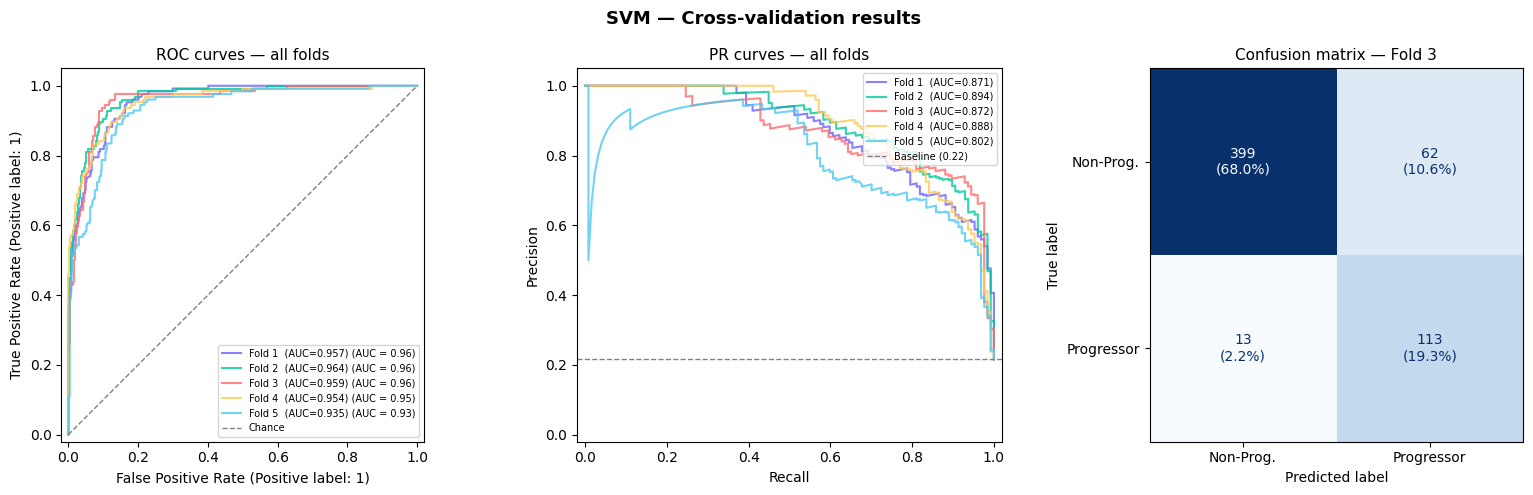

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("SVM — Cross-validation results", fontsize=13, fontweight="bold")

# ── ROC curves (all folds) ────────────────────────────────────────────────
ax = axes[0]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    auc = metrics_df.loc[fold_num, "roc_auc"]
    RocCurveDisplay.from_predictions(
        y_val, y_proba, ax=ax,
        name=f"Fold {fold_num}  (AUC={auc:.3f})",
        color=PALETTE[idx % len(PALETTE)],
        lw=1.5, alpha=0.8,
    )
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Chance")
ax.set_title("ROC curves — all folds", fontsize=11)
ax.legend(fontsize=7, loc="lower right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── PR curves (all folds) ─────────────────────────────────────────────────
ax = axes[1]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    pr_auc = metrics_df.loc[fold_num, "pr_auc"]
    precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_proba)
    ax.plot(recall_vals, precision_vals,
            color=PALETTE[idx % len(PALETTE)],
            lw=1.5, alpha=0.8,
            label=f"Fold {fold_num}  (AUC={pr_auc:.3f})")
baseline = sum(fold_data[-1][0]) / len(fold_data[-1][0])
ax.axhline(baseline, linestyle="--", color="gray", lw=1, label=f"Baseline ({baseline:.2f})")
ax.set_title("PR curves — all folds", fontsize=11)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=7, loc="upper right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── Confusion matrix (last fold) ─────────────────────────────────────────
ax = axes[2]
y_val_last, y_pred_last, _ = fold_data[best_fold]
cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_val_last, y_pred_last,
    ax=ax,
    display_labels=["Non-Prog.", "Progressor"],
    colorbar=False,
    cmap="Blues",
)
total = len(y_val_last)
for text_obj in cm_disp.text_.ravel():
    count = int(text_obj.get_text())
    text_obj.set_text(f"{count}\n({count/total*100:.1f}%)")
    text_obj.set_fontsize(10)
ax.set_title(f"Confusion matrix — Fold {best_fold}", fontsize=11)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

# **XGBoost del chef**




In [ ]:
# Class weight for imbalance
xgb_scale_pos_weight = 9
print(f"scale_pos_weight: {xgb_scale_pos_weight:.2f}")

XGB_THRESHOLD = 0.3

fold_metrics = []
fold_data    = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr,  X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr,  y_val = y.iloc[train_idx],         y.iloc[val_idx]

    scaler = StandardScaler()
    X_tr[scale_features]  = scaler.fit_transform(X_tr[scale_features])
    X_val[scale_features] = scaler.transform(X_val[scale_features])

    model = xgb.XGBClassifier(
        booster='gbtree',
        objective='binary:logistic',
        eval_metric='auc',
        scale_pos_weight=xgb_scale_pos_weight,
        random_state=42,
        verbosity=0,

        n_estimators=450,
        learning_rate=0.011904018053087056,
        max_depth=5,
        min_child_weight=14,
        subsample=0.7803454529027625,
        colsample_bytree=0.8037879721674877,
        gamma=0.35852119757873085,
        reg_alpha=1.3607206526502416,
        reg_lambda=1.948525020925154,
    )

    model.fit(X_tr, y_tr)

    y_proba = model.predict_proba(X_val)[:, 1]
    y_pred  = (y_proba >= XGB_THRESHOLD).astype(int)

                # --- train preds (for overfit check) ---
    y_pred_tr  = model.predict(X_tr)
    y_proba_tr = model.predict_proba(X_tr)[:, 1]

    fold_metrics.append({
        "fold":      fold,
        "roc_auc":   roc_auc_score(y_val, y_proba),
        "accuracy":  accuracy_score(y_val, y_pred),
        "recall":    recall_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "f1_score":  f1_score(y_val, y_pred, zero_division=0),
        "pr_auc":    average_precision_score(y_val, y_proba),

        "train_roc_auc":  roc_auc_score(y_tr, y_proba_tr),
        "train_accuracy": accuracy_score(y_tr, y_pred_tr),
        "train_recall":   recall_score(y_tr, y_pred_tr),
        "train_precision":precision_score(y_tr, y_pred_tr, zero_division=0),
        "train_f1":       f1_score(y_tr, y_pred_tr, zero_division=0),
        "train_pr_auc":   average_precision_score(y_tr, y_proba_tr),
    })
    fold_data.append((y_val, y_pred, y_proba))

metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
best_fold  = int(metrics_df["f1_score"].idxmax())

scale_pos_weight: 9.00


In [ ]:
cols    = ["roc_auc", "accuracy", "recall", "precision", "f1_score", "pr_auc"]
headers = ["Fold", "ROC-AUC", "Accuracy", "Recall", "Precision", "F1", "PR-AUC"]
col_w   = 10
sep     = "┼".join(["─" * col_w] * len(headers))

print(f"\n  {'XGBOOST Regression results':^{col_w * len(headers)}}")
print("  ┌" + "┬".join(["─" * col_w] * len(headers)) + "┐")
print("  │" + "│".join(h.center(col_w) for h in headers) + "│")
print("  ├" + sep + "┤")

for fold, row in metrics_df.iterrows():
    marker = f" ★Fold {fold}" if fold == best_fold else f"  Fold {fold}"
    cells  = [marker.ljust(col_w)]
    for c in cols:
        cells.append(f"{row[c]:.3f}".center(col_w))
    print("  │" + "│".join(cells) + "│")

print("  ├" + sep + "┤")
avg_cells = [" Mean".ljust(col_w)]
std_cells = [" Std".ljust(col_w)]
for c in cols:
    avg_cells.append(f"{metrics_df[c].mean():.3f}".center(col_w))
    std_cells.append(f"±{metrics_df[c].std():.3f}".center(col_w))
print("  │" + "│".join(avg_cells) + "│")
print("  │" + "│".join(std_cells) + "│")
print("  └" + "┴".join(["─" * col_w] * len(headers)) + "┘\n")

# ── Overfit / underfit diagnostics ──────────────────────────────────────────
metric_map = {
    "roc_auc": ("roc_auc",  "train_roc_auc"),
    "f1":      ("f1_score", "train_f1"),
    "pr_auc":  ("pr_auc",   "train_pr_auc"),
}

diag_headers = ["Metric", "Train", "Val", "Gap", "Status"]
diag_widths  = [14, 10, 10, 10, 14]
diag_sep     = "┼".join("─" * w for w in diag_widths)

print(f"\n  {'Fit Diagnostics':^{sum(diag_widths) + len(diag_widths) - 1}}")
print("  ┌" + "┬".join("─" * w for w in diag_widths) + "┐")
print("  │" + "│".join(h.center(w) for h, w in zip(diag_headers, diag_widths)) + "│")
print("  ├" + diag_sep + "┤")

flags = {}
for label, (val_col, tr_col) in metric_map.items():
    tr  = metrics_df[tr_col].mean()
    val = metrics_df[val_col].mean()
    gap = tr - val
    if gap > 0.10:
        flag = "⚠ overfit"
    elif val < 0.60:
        flag = "⚠ underfit"
    else:
        flag = "✓ ok"
    flags[label] = flag
    cells = [
        label.center(diag_widths[0]),
        f"{tr:.4f}".center(diag_widths[1]),
        f"{val:.4f}".center(diag_widths[2]),
        f"{gap:+.4f}".center(diag_widths[3]),
        flag.center(diag_widths[4]),
    ]
    print("  │" + "│".join(cells) + "│")

print("  └" + "┴".join("─" * w for w in diag_widths) + "┘")

# ── Summary banner ────────────────────────────────────────────────────────────
total_w = sum(diag_widths) + len(diag_widths) - 1
all_flags = list(flags.values())
if all(f == "✓ ok" for f in all_flags):
    verdict = "✓  Model fit looks healthy across all metrics"
elif any("overfit" in f for f in all_flags):
    bad = [k for k, v in flags.items() if "overfit" in v]
    verdict = f"⚠  Overfitting detected on: {', '.join(bad)}"
else:
    bad = [k for k, v in flags.items() if "underfit" in v]
    verdict = f"⚠  Underfitting detected on: {', '.join(bad)}"

print("  ┌" + "─" * total_w + "┐")
print("  │" + verdict.center(total_w) + "│")
print("  └" + "─" * total_w + "┘\n")


                        XGBOOST Regression results                      
  ┌──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
  │   Fold   │ ROC-AUC  │ Accuracy │  Recall  │Precision │    F1    │  PR-AUC  │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │  Fold 1  │  0.955   │  0.830   │  0.976   │  0.561   │  0.713   │  0.877   │
  │  Fold 2  │  0.970   │  0.847   │  0.976   │  0.588   │  0.734   │  0.908   │
  │ ★Fold 3  │  0.962   │  0.853   │  0.968   │  0.598   │  0.739   │  0.880   │
  │  Fold 4  │  0.959   │  0.835   │  0.952   │  0.569   │  0.712   │  0.896   │
  │  Fold 5  │  0.942   │  0.826   │  0.937   │  0.559   │  0.700   │  0.841   │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │ Mean     │  0.958   │  0.838   │  0.962   │  0.575   │  0.720   │  0.880   │
  │ Std      │  ±0.010  │  ±0.012  │  ±0.017  │  ±0.017  │  ±0.016  │  ±0.025  │
  └──────────┴──────────┴──────────

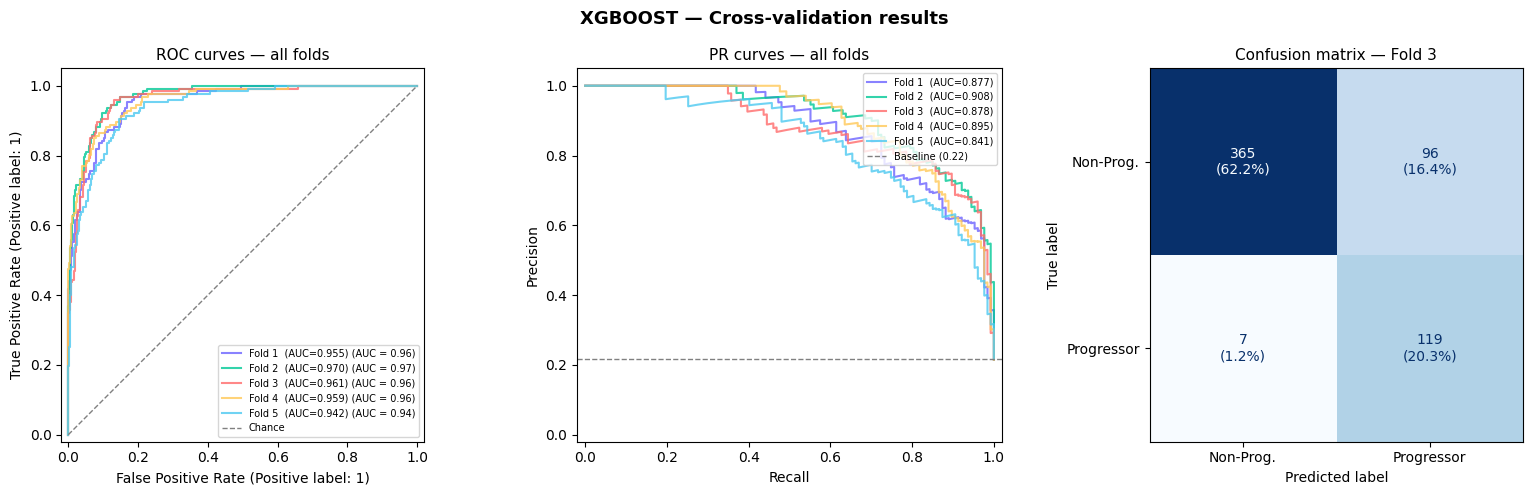

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("XGBOOST — Cross-validation results", fontsize=13, fontweight="bold")

# ── ROC curves (all folds) ────────────────────────────────────────────────
ax = axes[0]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    auc = metrics_df.loc[fold_num, "roc_auc"]
    RocCurveDisplay.from_predictions(
        y_val, y_proba, ax=ax,
        name=f"Fold {fold_num}  (AUC={auc:.3f})",
        color=PALETTE[idx % len(PALETTE)],
        lw=1.5, alpha=0.8,
    )
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Chance")
ax.set_title("ROC curves — all folds", fontsize=11)
ax.legend(fontsize=7, loc="lower right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── PR curves (all folds) ─────────────────────────────────────────────────
ax = axes[1]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    pr_auc = metrics_df.loc[fold_num, "pr_auc"]
    precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_proba)
    ax.plot(recall_vals, precision_vals,
            color=PALETTE[idx % len(PALETTE)],
            lw=1.5, alpha=0.8,
            label=f"Fold {fold_num}  (AUC={pr_auc:.3f})")
baseline = sum(fold_data[-1][0]) / len(fold_data[-1][0])
ax.axhline(baseline, linestyle="--", color="gray", lw=1, label=f"Baseline ({baseline:.2f})")
ax.set_title("PR curves — all folds", fontsize=11)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=7, loc="upper right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── Confusion matrix (last fold) ─────────────────────────────────────────
ax = axes[2]
y_val_last, y_pred_last, _ = fold_data[best_fold]
cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_val_last, y_pred_last,
    ax=ax,
    display_labels=["Non-Prog.", "Progressor"],
    colorbar=False,
    cmap="Blues",
)
total = len(y_val_last)
for text_obj in cm_disp.text_.ravel():
    count = int(text_obj.get_text())
    text_obj.set_text(f"{count}\n({count/total*100:.1f}%)")
    text_obj.set_fontsize(10)
ax.set_title(f"Confusion matrix — Fold {best_fold}", fontsize=11)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

# الغابه العشوائيه

In [ ]:
RF_THRESHOLD = 0.3

rf =RandomForestClassifier(
    # ── core regularization ──────────────────────────────
    n_estimators=300,         # more trees = more stable, not more overfit
    max_depth=8,              # was None (unlimited) → hard cap on tree depth
    min_samples_leaf=10,      # each leaf must cover ≥10 samples, prevents tiny splits
    min_samples_split=20,     # node must have ≥20 samples before splitting
    max_features="sqrt",      # already default for classifiers, keep it
    max_samples=0.8,          # each tree sees only 80% of training rows (row subsampling)

    # ── class imbalance ──────────────────────────────────
    class_weight="balanced",  # keeps recall high without inflating train F1

    random_state=42,
    n_jobs=-1,
)

fold_metrics = []
fold_data    = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr,  X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr,  y_val = y.iloc[train_idx],         y.iloc[val_idx]

    scaler = StandardScaler()
    X_tr[scale_features]  = scaler.fit_transform(X_tr[scale_features])
    X_val[scale_features] = scaler.transform(X_val[scale_features])

    rf.fit(X_tr, y_tr)

    y_proba = rf.predict_proba(X_val)[:, 1]
    y_pred  = (y_proba >= RF_THRESHOLD).astype(int)

    # --- train preds (for overfit check) ---
    y_pred_tr  = rf.predict(X_tr)
    y_proba_tr = rf.predict_proba(X_tr)[:, 1]

    fold_metrics.append({
        "fold":      fold,
        "roc_auc":   roc_auc_score(y_val, y_proba),
        "accuracy":  accuracy_score(y_val, y_pred),
        "recall":    recall_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "f1_score":  f1_score(y_val, y_pred, zero_division=0),
        "pr_auc":    average_precision_score(y_val, y_proba),

        "train_roc_auc":  roc_auc_score(y_tr, y_proba_tr),
        "train_accuracy": accuracy_score(y_tr, y_pred_tr),
        "train_recall":   recall_score(y_tr, y_pred_tr),
        "train_precision":precision_score(y_tr, y_pred_tr, zero_division=0),
        "train_f1":       f1_score(y_tr, y_pred_tr, zero_division=0),
        "train_pr_auc":   average_precision_score(y_tr, y_proba_tr),
    })
    fold_data.append((y_val, y_pred, y_proba))

metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
best_fold  = int(metrics_df["f1_score"].idxmax())

In [ ]:
cols    = ["roc_auc", "accuracy", "recall", "precision", "f1_score", "pr_auc"]
headers = ["Fold", "ROC-AUC", "Accuracy", "Recall", "Precision", "F1", "PR-AUC"]
col_w   = 10
sep     = "┼".join(["─" * col_w] * len(headers))

print(f"\n  {'Random Forest results':^{col_w * len(headers)}}")
print("  ┌" + "┬".join(["─" * col_w] * len(headers)) + "┐")
print("  │" + "│".join(h.center(col_w) for h in headers) + "│")
print("  ├" + sep + "┤")

for fold, row in metrics_df.iterrows():
    marker = f" ★Fold {fold}" if fold == best_fold else f"  Fold {fold}"
    cells  = [marker.ljust(col_w)]
    for c in cols:
        cells.append(f"{row[c]:.3f}".center(col_w))
    print("  │" + "│".join(cells) + "│")

print("  ├" + sep + "┤")
avg_cells = [" Mean".ljust(col_w)]
std_cells = [" Std".ljust(col_w)]
for c in cols:
    avg_cells.append(f"{metrics_df[c].mean():.3f}".center(col_w))
    std_cells.append(f"±{metrics_df[c].std():.3f}".center(col_w))
print("  │" + "│".join(avg_cells) + "│")
print("  │" + "│".join(std_cells) + "│")
print("  └" + "┴".join(["─" * col_w] * len(headers)) + "┘\n")

# ── Overfit / underfit diagnostics ──────────────────────────────────────────
metric_map = {
    "roc_auc": ("roc_auc",  "train_roc_auc"),
    "f1":      ("f1_score", "train_f1"),
    "pr_auc":  ("pr_auc",   "train_pr_auc"),
}

diag_headers = ["Metric", "Train", "Val", "Gap", "Status"]
diag_widths  = [14, 10, 10, 10, 14]
diag_sep     = "┼".join("─" * w for w in diag_widths)

print(f"\n  {'Fit Diagnostics':^{sum(diag_widths) + len(diag_widths) - 1}}")
print("  ┌" + "┬".join("─" * w for w in diag_widths) + "┐")
print("  │" + "│".join(h.center(w) for h, w in zip(diag_headers, diag_widths)) + "│")
print("  ├" + diag_sep + "┤")

flags = {}
for label, (val_col, tr_col) in metric_map.items():
    tr  = metrics_df[tr_col].mean()
    val = metrics_df[val_col].mean()
    gap = tr - val
    if gap > 0.10:
        flag = "⚠ overfit"
    elif val < 0.60:
        flag = "⚠ underfit"
    else:
        flag = "✓ ok"
    flags[label] = flag
    cells = [
        label.center(diag_widths[0]),
        f"{tr:.4f}".center(diag_widths[1]),
        f"{val:.4f}".center(diag_widths[2]),
        f"{gap:+.4f}".center(diag_widths[3]),
        flag.center(diag_widths[4]),
    ]
    print("  │" + "│".join(cells) + "│")

print("  └" + "┴".join("─" * w for w in diag_widths) + "┘")

# ── Summary banner ────────────────────────────────────────────────────────────
total_w = sum(diag_widths) + len(diag_widths) - 1
all_flags = list(flags.values())
if all(f == "✓ ok" for f in all_flags):
    verdict = "✓  Model fit looks healthy across all metrics"
elif any("overfit" in f for f in all_flags):
    bad = [k for k, v in flags.items() if "overfit" in v]
    verdict = f"⚠  Overfitting detected on: {', '.join(bad)}"
else:
    bad = [k for k, v in flags.items() if "underfit" in v]
    verdict = f"⚠  Underfitting detected on: {', '.join(bad)}"

print("  ┌" + "─" * total_w + "┐")
print("  │" + verdict.center(total_w) + "│")
print("  └" + "─" * total_w + "┘\n")


                          Random Forest results                         
  ┌──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
  │   Fold   │ ROC-AUC  │ Accuracy │  Recall  │Precision │    F1    │  PR-AUC  │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │  Fold 1  │  0.954   │  0.835   │  0.929   │  0.573   │  0.709   │  0.868   │
  │  Fold 2  │  0.965   │  0.864   │  0.969   │  0.618   │  0.755   │  0.897   │
  │ ★Fold 3  │  0.956   │  0.867   │  0.960   │  0.624   │  0.756   │  0.868   │
  │  Fold 4  │  0.956   │  0.842   │  0.937   │  0.581   │  0.717   │  0.888   │
  │  Fold 5  │  0.941   │  0.848   │  0.913   │  0.598   │  0.723   │  0.836   │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │ Mean     │  0.954   │  0.851   │  0.942   │  0.599   │  0.732   │  0.871   │
  │ Std      │  ±0.009  │  ±0.014  │  ±0.023  │  ±0.022  │  ±0.022  │  ±0.023  │
  └──────────┴──────────┴──────────

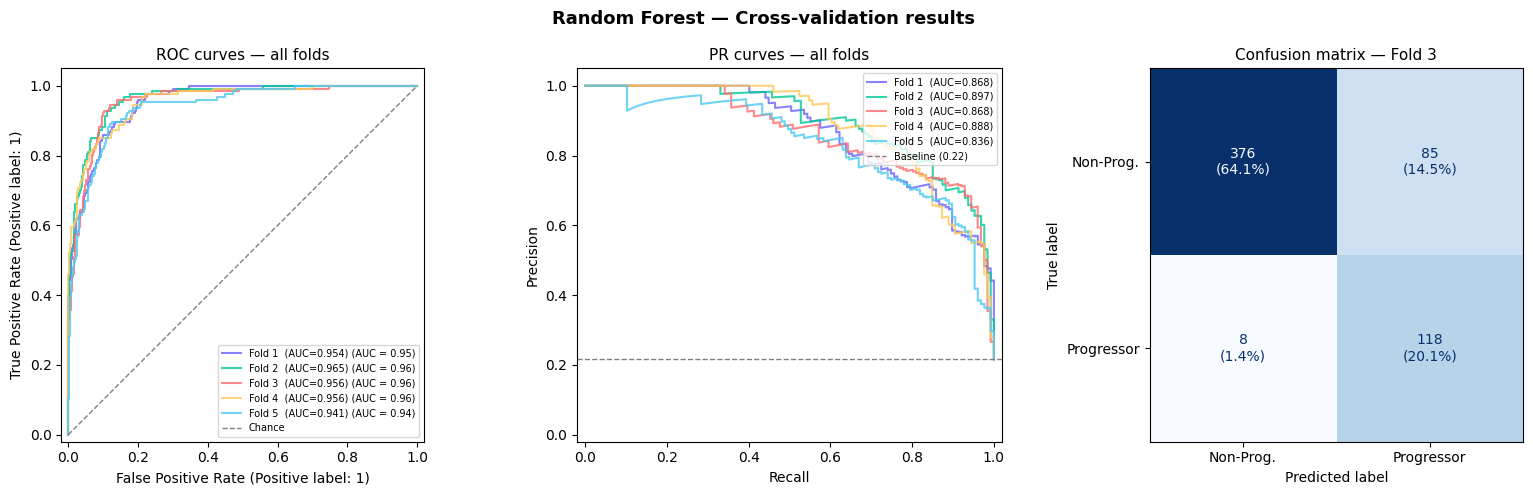

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Random Forest — Cross-validation results", fontsize=13, fontweight="bold")

# ── ROC curves (all folds) ────────────────────────────────────────────────
ax = axes[0]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    auc = metrics_df.loc[fold_num, "roc_auc"]
    RocCurveDisplay.from_predictions(
        y_val, y_proba, ax=ax,
        name=f"Fold {fold_num}  (AUC={auc:.3f})",
        color=PALETTE[idx % len(PALETTE)],
        lw=1.5, alpha=0.8,
    )
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Chance")
ax.set_title("ROC curves — all folds", fontsize=11)
ax.legend(fontsize=7, loc="lower right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── PR curves (all folds) ─────────────────────────────────────────────────
ax = axes[1]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    pr_auc = metrics_df.loc[fold_num, "pr_auc"]
    precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_proba)
    ax.plot(recall_vals, precision_vals,
            color=PALETTE[idx % len(PALETTE)],
            lw=1.5, alpha=0.8,
            label=f"Fold {fold_num}  (AUC={pr_auc:.3f})")
baseline = sum(fold_data[-1][0]) / len(fold_data[-1][0])
ax.axhline(baseline, linestyle="--", color="gray", lw=1, label=f"Baseline ({baseline:.2f})")
ax.set_title("PR curves — all folds", fontsize=11)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=7, loc="upper right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── Confusion matrix (last fold) ─────────────────────────────────────────
ax = axes[2]
y_val_last, y_pred_last, _ = fold_data[best_fold]
cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_val_last, y_pred_last,
    ax=ax,
    display_labels=["Non-Prog.", "Progressor"],
    colorbar=False,
    cmap="Blues",
)
total = len(y_val_last)
for text_obj in cm_disp.text_.ravel():
    count = int(text_obj.get_text())
    text_obj.set_text(f"{count}\n({count/total*100:.1f}%)")
    text_obj.set_fontsize(10)
ax.set_title(f"Confusion matrix — Fold {best_fold}", fontsize=11)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

# 🕸️الشبكه العنكبتويه🕸️

In [ ]:
tf.random.set_seed(42)


neg, pos = (y == 0).sum(), (y == 1).sum()
class_weight =  {0: 1.0, 1: neg / pos * 1.3}
print(f"Class weight for Progressor: {class_weight[1]:.2f}")

def build_model(input_dim):
    inp = keras.Input(shape=(input_dim,))

    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(32, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)

    out = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    return model

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, mode='min',
                  restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10,
                      mode='min', min_lr=1e-6, verbose=0)
]

NN_THRESHOLD = 0.5
EPOCHS = 300
BATCH_SIZE = 8

fold_metrics = []
fold_data = []
fold_models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler = StandardScaler()
    X_tr[scale_features] = scaler.fit_transform(X_tr[scale_features])
    X_val[scale_features] = scaler.transform(X_val[scale_features])

    tf.random.set_seed(42 + fold)
    nn_model = build_model(X_tr.shape[1])
    nn_model.fit(X_tr, y_tr,
                 validation_data=(X_val, y_val),
                 epochs=EPOCHS, batch_size=BATCH_SIZE,
                 class_weight=class_weight,
                 callbacks=callbacks, verbose=0)

    y_proba = nn_model.predict(X_val, verbose=0).ravel()
    y_pred = (y_proba >= NN_THRESHOLD).astype(int)

    y_proba_tr = nn_model.predict(X_tr, verbose=0).ravel()
    y_pred_tr = (y_proba_tr >= NN_THRESHOLD).astype(int)

    fold_metrics.append({
        "fold": fold,
        "roc_auc": roc_auc_score(y_val, y_proba),
        "accuracy": accuracy_score(y_val, y_pred),
        "recall": recall_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "f1_score": f1_score(y_val, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_val, y_proba),
        "train_roc_auc": roc_auc_score(y_tr, y_proba_tr),
        "train_accuracy": accuracy_score(y_tr, y_pred_tr),
        "train_recall": recall_score(y_tr, y_pred_tr),
        "train_precision": precision_score(y_tr, y_pred_tr, zero_division=0),
        "train_f1": f1_score(y_tr, y_pred_tr, zero_division=0),
        "train_pr_auc": average_precision_score(y_tr, y_proba_tr),
    })
    fold_data.append((y_val, y_pred, y_proba))
    fold_models.append((nn_model, scaler))

metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
best_fold = int(metrics_df["f1_score"].idxmax())

Class weight for Progressor: 4.73


In [ ]:
cols    = ["roc_auc", "accuracy", "recall", "precision", "f1_score", "pr_auc"]
headers = ["Fold", "ROC-AUC", "Accuracy", "Recall", "Precision", "F1", "PR-AUC"]
col_w   = 10
sep     = "┼".join(["─" * col_w] * len(headers))

print(f"\n  {'MLP results':^{col_w * len(headers)}}")
print("  ┌" + "┬".join(["─" * col_w] * len(headers)) + "┐")
print("  │" + "│".join(h.center(col_w) for h in headers) + "│")
print("  ├" + sep + "┤")

for fold, row in metrics_df.iterrows():
    marker = f" ★Fold {fold}" if fold == best_fold else f"  Fold {fold}"
    cells  = [marker.ljust(col_w)]
    for c in cols:
        cells.append(f"{row[c]:.3f}".center(col_w))
    print("  │" + "│".join(cells) + "│")

print("  ├" + sep + "┤")
avg_cells = [" Mean".ljust(col_w)]
std_cells = [" Std".ljust(col_w)]
for c in cols:
    avg_cells.append(f"{metrics_df[c].mean():.3f}".center(col_w))
    std_cells.append(f"±{metrics_df[c].std():.3f}".center(col_w))
print("  │" + "│".join(avg_cells) + "│")
print("  │" + "│".join(std_cells) + "│")
print("  └" + "┴".join(["─" * col_w] * len(headers)) + "┘\n")

# ── Overfit / underfit diagnostics ──────────────────────────────────────────
metric_map = {
    "roc_auc": ("roc_auc",  "train_roc_auc"),
    "f1":      ("f1_score", "train_f1"),
    "pr_auc":  ("pr_auc",   "train_pr_auc"),
}

diag_headers = ["Metric", "Train", "Val", "Gap", "Status"]
diag_widths  = [14, 10, 10, 10, 14]
diag_sep     = "┼".join("─" * w for w in diag_widths)

print(f"\n  {'Fit Diagnostics':^{sum(diag_widths) + len(diag_widths) - 1}}")
print("  ┌" + "┬".join("─" * w for w in diag_widths) + "┐")
print("  │" + "│".join(h.center(w) for h, w in zip(diag_headers, diag_widths)) + "│")
print("  ├" + diag_sep + "┤")

flags = {}
for label, (val_col, tr_col) in metric_map.items():
    tr  = metrics_df[tr_col].mean()
    val = metrics_df[val_col].mean()
    gap = tr - val
    if gap > 0.10:
        flag = "⚠ overfit"
    elif val < 0.60:
        flag = "⚠ underfit"
    else:
        flag = "✓ ok"
    flags[label] = flag
    cells = [
        label.center(diag_widths[0]),
        f"{tr:.4f}".center(diag_widths[1]),
        f"{val:.4f}".center(diag_widths[2]),
        f"{gap:+.4f}".center(diag_widths[3]),
        flag.center(diag_widths[4]),
    ]
    print("  │" + "│".join(cells) + "│")

print("  └" + "┴".join("─" * w for w in diag_widths) + "┘")

# ── Summary banner ────────────────────────────────────────────────────────────
total_w = sum(diag_widths) + len(diag_widths) - 1
all_flags = list(flags.values())
if all(f == "✓ ok" for f in all_flags):
    verdict = "✓  Model fit looks healthy across all metrics"
elif any("overfit" in f for f in all_flags):
    bad = [k for k, v in flags.items() if "overfit" in v]
    verdict = f"⚠  Overfitting detected on: {', '.join(bad)}"
else:
    bad = [k for k, v in flags.items() if "underfit" in v]
    verdict = f"⚠  Underfitting detected on: {', '.join(bad)}"

print("  ┌" + "─" * total_w + "┐")
print("  │" + verdict.center(total_w) + "│")
print("  └" + "─" * total_w + "┘\n")


                               MLP results                              
  ┌──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
  │   Fold   │ ROC-AUC  │ Accuracy │  Recall  │Precision │    F1    │  PR-AUC  │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │ ★Fold 1  │  0.957   │  0.901   │  0.913   │  0.712   │  0.800   │  0.857   │
  │  Fold 2  │  0.962   │  0.871   │  0.937   │  0.636   │  0.758   │  0.879   │
  │  Fold 3  │  0.961   │  0.884   │  0.952   │  0.659   │  0.779   │  0.880   │
  │  Fold 4  │  0.955   │  0.855   │  0.897   │  0.611   │  0.727   │  0.881   │
  │  Fold 5  │  0.933   │  0.862   │  0.890   │  0.628   │  0.736   │  0.826   │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │ Mean     │  0.954   │  0.875   │  0.918   │  0.649   │  0.760   │  0.864   │
  │ Std      │  ±0.012  │  ±0.018  │  ±0.027  │  ±0.039  │  ±0.030  │  ±0.024  │
  └──────────┴──────────┴──────────

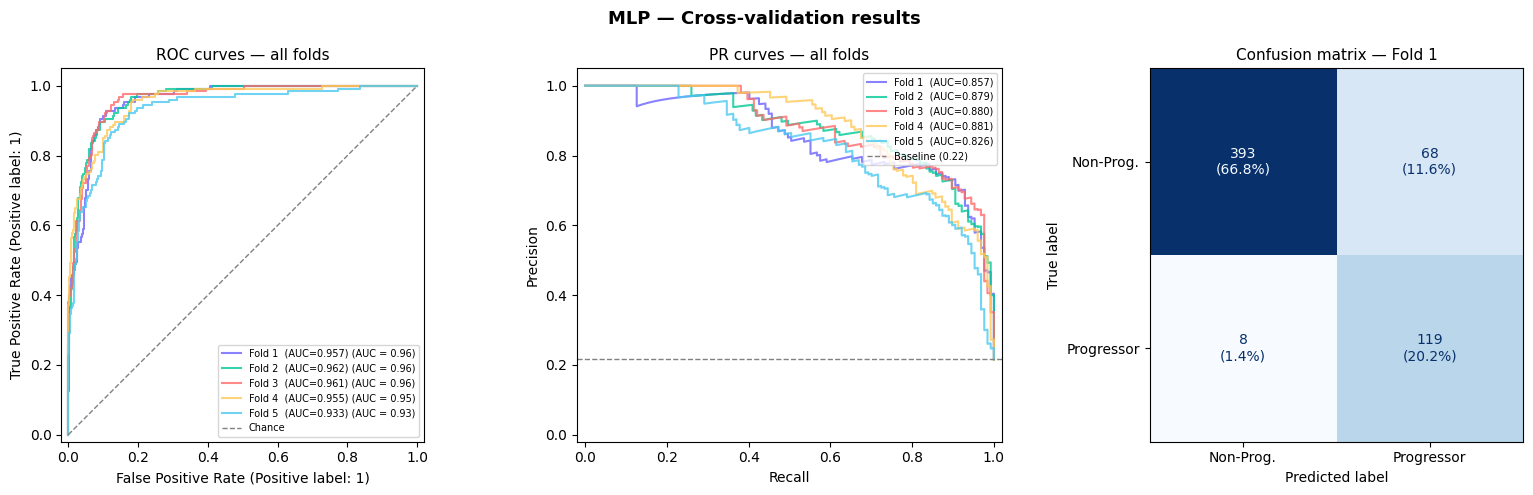

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("MLP — Cross-validation results", fontsize=13, fontweight="bold")

# ── ROC curves (all folds) ────────────────────────────────────────────────
ax = axes[0]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    auc = metrics_df.loc[fold_num, "roc_auc"]
    RocCurveDisplay.from_predictions(
        y_val, y_proba, ax=ax,
        name=f"Fold {fold_num}  (AUC={auc:.3f})",
        color=PALETTE[idx % len(PALETTE)],
        lw=1.5, alpha=0.8,
    )
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Chance")
ax.set_title("ROC curves — all folds", fontsize=11)
ax.legend(fontsize=7, loc="lower right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── PR curves (all folds) ─────────────────────────────────────────────────
ax = axes[1]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    pr_auc = metrics_df.loc[fold_num, "pr_auc"]
    precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_proba)
    ax.plot(recall_vals, precision_vals,
            color=PALETTE[idx % len(PALETTE)],
            lw=1.5, alpha=0.8,
            label=f"Fold {fold_num}  (AUC={pr_auc:.3f})")
baseline = sum(fold_data[-1][0]) / len(fold_data[-1][0])
ax.axhline(baseline, linestyle="--", color="gray", lw=1, label=f"Baseline ({baseline:.2f})")
ax.set_title("PR curves — all folds", fontsize=11)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=7, loc="upper right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── Confusion matrix (last fold) ─────────────────────────────────────────
ax = axes[2]
y_val_last, y_pred_last, _ = fold_data[best_fold]
cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_val_last, y_pred_last,
    ax=ax,
    display_labels=["Non-Prog.", "Progressor"],
    colorbar=False,
    cmap="Blues",
)
total = len(y_val_last)
for text_obj in cm_disp.text_.ravel():
    count = int(text_obj.get_text())
    text_obj.set_text(f"{count}\n({count/total*100:.1f}%)")
    text_obj.set_fontsize(10)
ax.set_title(f"Confusion matrix — Fold {best_fold}", fontsize=11)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

# مجلس الشعب

In [ ]:
#Hi ahmed
#Hi omar
#ana nadeem
#Karim galkooo
#nadeem shof el 2 models dol
#HI KIMO
#hru
#DEAR AHMED,OMAR THIS THE WORST MODELS HUMANS HAVE EVER MADE
#plz ask the leader for guidance
#NOT BEST REGARDS, عده ذكيه تيم  👎
#best regards for u kimo
#                                 BEST TEAM LEADER 😎
#I will fix this shit b3d gamen league keda.
#USE THE FEATURES IN GENARL USE CELL AND scale_features and skf
# NO

In [ ]:
# LOTS OF LOVE TO ALL THE TEAM WHITE MEMBERS 🤍

In [ ]:
# (25%)² (LOTS OF LOVE TO ALL THE TEAM BLACK MEMBERS)

In [ ]:
# 1000%(LOTS OF LOVE TO ALL THE TEAM MEMBERS THAT PLAY LEAGUE W Overwatch(لنا عوده))

In [ ]:
# (Lots of hate to all the team black members)²

In [ ]:
# lots of hate to all ratatouille and michelin

In [ ]:
# KHOBZA W SHAWRMA BEST FAST FOOD RESTURANT IN GIZA

In [ ]:
# lots of hate to SUMMER

In [ ]:
# (10000 % lots of hate to all summer lovers ) **2

In [ ]:
# lots and lots of love to winter

In [ ]:
# (lots of love and recpect to any one who loves WINTER (exept Nadeem and Fahmi) ) ** 20

In [ ]:
# Any one who hates SUMMER is my friend

In [ ]:
# Summer 👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎

In [ ]:
# WINTER 👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻

In [ ]:
#for user in users_list:
#     if user love summer:
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)
#           kill(user)

In [ ]:
#DATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARDATAISNONLINEARv

In [ ]:
#ALL GLORY MASTER ratatouille
# T7yati🌹